# SSH Chain Edge-State Filtering

This notebook builds a finite Su-Schrieffer-Heeger chain with open boundaries. In the topological regime, the spectrum has near-zero edge states separated from the bulk bands.

We use a bounded polynomial filter centered near zero energy to isolate the edge subspace. This is a concrete condensed-matter example of QSVT-style spectral filtering.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

## Build the dimerized chain

The hopping amplitudes alternate between `t1` and `t2`. For `t1 < t2`, an open chain has edge-localized modes near zero energy.


In [2]:
n_cells = 8
n_sites = 2 * n_cells
t1 = 0.55
t2 = 1.0

H = np.zeros((n_sites, n_sites))
for cell in range(n_cells):
    left = 2 * cell
    right = left + 1
    H[left, right] = H[right, left] = -t1
    if cell < n_cells - 1:
        H[right, right + 1] = H[right + 1, right] = -t2

eigenvalues, eigenvectors = eigh_hermitian(H)
scale = np.max(np.abs(eigenvalues))
A = H / scale

near_zero = eigenvalues[n_sites // 2 - 2 : n_sites // 2 + 2]
near_zero

array([-0.5577, -0.0058,  0.0058,  0.5577])

## Filter the zero-energy edge subspace

A Gaussian-shaped polynomial in the rescaled energy isolates states close to zero. The resulting matrix is a soft projector onto the edge-mode subspace.


In [3]:
degree = 28
width = 0.18
fit_x = np.linspace(-1.0, 1.0, 1201)
fit_target = np.exp(-((fit_x / width) ** 2))
coeffs = np.polynomial.polynomial.polyfit(fit_x, fit_target, degree)

soft_edge_projector = apply_polynomial_to_hermitian(A, coeffs)
site_weight = np.real(np.diag(soft_edge_projector))
edge_weight_fraction = np.sum(site_weight[[0, 1, -2, -1]]) / np.trace(
    soft_edge_projector
)

edge_weight_fraction, np.trace(soft_edge_projector)

(np.float64(0.6880404379008599), np.float64(2.0327822807342835))

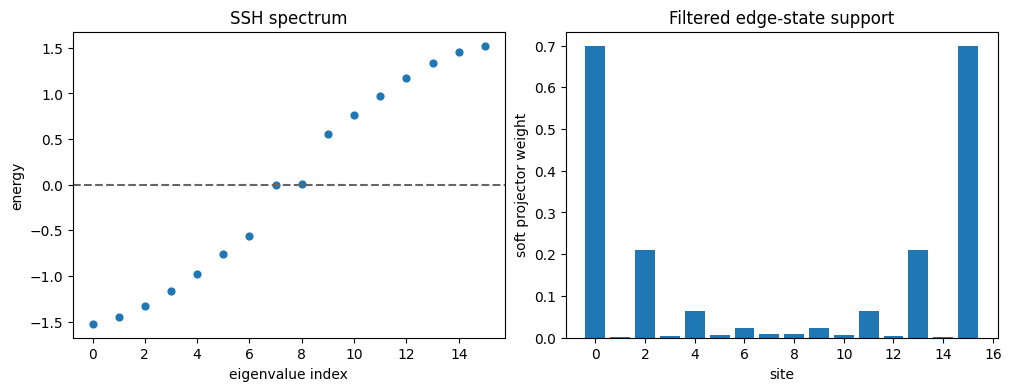

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

axes[0].scatter(np.arange(n_sites), eigenvalues, s=24)
axes[0].axhline(0.0, color="0.4", linestyle="--")
axes[0].set_xlabel("eigenvalue index")
axes[0].set_ylabel("energy")
axes[0].set_title("SSH spectrum")

axes[1].bar(np.arange(n_sites), site_weight)
axes[1].set_xlabel("site")
axes[1].set_ylabel("soft projector weight")
axes[1].set_title("Filtered edge-state support")

plt.show()

## Validation

Compact checks for the expected topological edge-state behavior.


In [5]:
assert np.max(np.abs(eigenvalues[n_sites // 2 - 1 : n_sites // 2 + 1])) < 0.02
assert edge_weight_fraction > 0.55
assert 1.5 < np.trace(soft_edge_projector) < 2.5

print("near_zero_eigenvalues:", np.array2string(near_zero, precision=5))
print(f"edge_weight_fraction: {edge_weight_fraction:.3f}")
print(f"projector_trace: {np.trace(soft_edge_projector):.3f}")
print("validation: passed")

near_zero_eigenvalues: [-0.55766 -0.00584  0.00584  0.55766]
edge_weight_fraction: 0.688
projector_trace: 2.033
validation: passed
